# Tag Alterations Database Analysis

## 1. Import Libraries

In [1]:
import sqlite3
import pandas as pd
import numpy as np
pd.set_option('display.max_colwidth', None)
print("Libraries imported successfully")

Libraries imported successfully


## 2. Connect to Database and Load Data

In [2]:
conn = sqlite3.connect('../data/tags_alterations_full_2025-05_v2.db')
df = pd.read_sql_query("SELECT * FROM tag_inconsistencies", conn)

print(f"Loaded {len(df)} tag inconsistencies from database")

Loaded 12673979 tag inconsistencies from database


In [3]:
for col in ['old_snap_timestamp', 'old_rev_timestamp', 'new_snap_timestamp', 'new_rev_timestamp']:
    df[col] = pd.to_datetime(df[col], unit='s', errors='coerce')


In [4]:
df['year'] = df['new_snap_timestamp'].dt.year
df['type'] = df['new_revision'].apply(lambda x: 'Alteration' if pd.notna(x) else 'Deletion')

## 3. Explore the DataFrame

In [5]:
print("DataFrame shape:", df.shape)
df.head()

DataFrame shape: (12673979, 15)


,id,origin_url,tag_name,old_snapshot,old_snap_timestamp,old_revision,old_rev_timestamp,old_root_dir,new_snapshot,new_snap_timestamp,new_revision,new_rev_timestamp,new_root_dir,year,type
0,1,https://github.com/xportation/agoga,refs/tags/1.1,swh:1:snp:d033fb1ea3a1cb497a67e85b95b76c2ebbd220ac,2020-03-28 02:44:49,swh:1:rev:886469ce8e78e48e4bd0824101ea0feb37260a12,2017-09-03 23:43:00,swh:1:dir:de329b4150a49a16e736ce902440121d72c460d9,swh:1:snp:394f209105e6fdbba33c8d3559f6110189c5525d,2021-06-25 04:49:47,None,NaT,None,2021,Deletion
1,2,https://github.com/xportation/agoga,refs/tags/1.0,swh:1:snp:d033fb1ea3a1cb497a67e85b95b76c2ebbd220ac,2020-03-28 02:44:49,swh:1:rev:42c0c3732a7cbaf18f43db8789842986145a9070,2017-09-03 00:19:35,swh:1:dir:4b5867b23908ca0e2e107ac67845858ea6a23b67,swh:1:snp:394f209105e6fdbba33c8d3559f6110189c5525d,2021-06-25 04:49:47,None,NaT,None,2021,Deletion
2,3,https://github.com/francois-docker/firefox,refs/tags/35.0.1,swh:1:snp:d7ab28e5318212aeca5df86527f79892ac913c12,2016-03-15 23:04:03,swh:1:rev:0721f0939821e5b0576c9510ce0e7a1a2626e975,2015-02-27 12:27:09,swh:1:dir:052c184624cc59385bbef8f1c1fff71ce403dbea,swh:1:snp:a22aa73939b8ea3a10aba9eef4dadb4bc051bc5c,2018-09-28 07:03:38,None,NaT,None,2018,Deletion
3,4,https://github.com/chenqian0824/chenqian0824.github.io,refs/tags/v1.1,swh:1:snp:bdbc3b49e686f8db950ea0940aecf0529c0d3f1f,2020-05-16 10:06:13,swh:1:rev:e48e10e6fa2991964c24cce5bedadefd7cbbb272,2017-02-14 09:34:47,swh:1:dir:c8717db886d004344a911fb1c3716b00a6da2d36,swh:1:snp:c18bfe3bd377664edea05dcfabf8d88de9f9507d,2021-06-19 08:19:14,None,NaT,None,2021,Deletion
4,5,https://github.com/chenqian0824/chenqian0824.github.io,refs/tags/v1.0,swh:1:snp:bdbc3b49e686f8db950ea0940aecf0529c0d3f1f,2020-05-16 10:06:13,swh:1:rev:bbc1feb3c09bace83499cfdf54d131a66cde3b03,2017-02-10 08:33:36,swh:1:dir:1dae201310b70e56c213f48d81d47aa97f4c911d,swh:1:snp:c18bfe3bd377664edea05dcfabf8d88de9f9507d,2021-06-19 08:19:14,None,NaT,None,2021,Deletion


## 4. Queries

In [6]:
tag_deletions = df[df['new_revision'].isnull()]
tag_alterations = df[df['new_revision'].notnull()]

print(f"Tag Alterations: {len(tag_alterations)}")
print(f"Tag Deletions: {len(tag_deletions)}")
print(f"Total: {len(df)}")

Tag Alterations: 171356
Tag Deletions: 12502623
Total: 12673979


In [7]:
# Find origins with most tag inconsistencies
origins_with_most_issues = df.groupby('origin_url').size().sort_values(ascending=False)
print("Top 10 origins with most tag inconsistencies:")
origins_with_most_issues.head(10)

Top 10 origins with most tag inconsistencies:


origin_url
https://github.com/aws/aws-sdk-go-v2                       3890156
https://android.googlesource.com/platform/system/extras     186288
https://github.com/CleverRaven/Cataclysm-DDA                180071
https://android.googlesource.com/platform/bionic            177499
https://github.com/apple/swift-corelibs-libdispatch         131746
https://github.com/boto/boto3                               120019
https://github.com/aws/aws-cli                              110499
https://github.com/open-telemetry/opentelemetry-go           76817
https://github.com/vim/vim                                   70188
https://github.com/JetBrains/intellij-community              65001
dtype: int64

In [8]:
tag_alterations[['origin_url', 'tag_name', 'old_snapshot', 'new_snapshot', 'old_snap_timestamp', 'new_snap_timestamp', 'old_rev_timestamp', 'new_rev_timestamp']].head()

,origin_url,tag_name,old_snapshot,new_snapshot,old_snap_timestamp,new_snap_timestamp,old_rev_timestamp,new_rev_timestamp
6,https://github.com/feather-team/feather-ui2.0,refs/tags/v2.0.0,swh:1:snp:a7930d8b962a2b993a434c2c880325d53215c6e6,swh:1:snp:631e98d9dd49dcf9e99b6532674c531b177ec044,2016-07-30 07:14:06,2016-08-15 23:43:59,2016-07-14 07:04:43,2016-08-15 09:21:27
7,https://github.com/feather-team/feather-ui2.0,refs/tags/v2.0.0,swh:1:snp:631e98d9dd49dcf9e99b6532674c531b177ec044,swh:1:snp:8ffa502b8f966fa9f6ce26602b1b1695cc78ad42,2016-08-15 23:43:59,2016-12-04 20:55:36,2016-08-15 09:21:27,2016-11-09 08:37:59
92,https://github.com/ColdBox/cbox-debugger,refs/tags/v1.1.0,swh:1:snp:e8545001eb17e0a968b86d8be020188e06d3d22d,swh:1:snp:fd98ced6b988651a0f57ecfd1bead8a8d33c18eb,2016-03-01 00:41:17,2016-03-18 15:38:52,2015-02-04 18:39:20,2015-02-04 18:39:20
93,https://github.com/ColdBox/cbox-debugger,refs/tags/v1.0.1,swh:1:snp:e8545001eb17e0a968b86d8be020188e06d3d22d,swh:1:snp:fd98ced6b988651a0f57ecfd1bead8a8d33c18eb,2016-03-01 00:41:17,2016-03-18 15:38:52,2014-12-09 21:52:54,2014-12-09 21:52:54
94,https://github.com/ColdBox/cbox-debugger,refs/tags/v1.2.0,swh:1:snp:e8545001eb17e0a968b86d8be020188e06d3d22d,swh:1:snp:fd98ced6b988651a0f57ecfd1bead8a8d33c18eb,2016-03-01 00:41:17,2016-03-18 15:38:52,2015-12-03 19:51:55,2015-12-03 19:51:55


In [9]:
df[df['origin_url'].apply(lambda x: 'github' in x)]

,id,origin_url,tag_name,old_snapshot,old_snap_timestamp,old_revision,old_rev_timestamp,old_root_dir,new_snapshot,new_snap_timestamp,new_revision,new_rev_timestamp,new_root_dir,year,type
0,1,https://github.com/xportation/agoga,refs/tags/1.1,swh:1:snp:d033fb1ea3a1cb497a67e85b95b76c2ebbd220ac,2020-03-28 02:44:49,swh:1:rev:886469ce8e78e48e4bd0824101ea0feb37260a12,2017-09-03 23:43:00,swh:1:dir:de329b4150a49a16e736ce902440121d72c460d9,swh:1:snp:394f209105e6fdbba33c8d3559f6110189c5525d,2021-06-25 04:49:47,None,NaT,None,2021,Deletion
1,2,https://github.com/xportation/agoga,refs/tags/1.0,swh:1:snp:d033fb1ea3a1cb497a67e85b95b76c2ebbd220ac,2020-03-28 02:44:49,swh:1:rev:42c0c3732a7cbaf18f43db8789842986145a9070,2017-09-03 00:19:35,swh:1:dir:4b5867b23908ca0e2e107ac67845858ea6a23b67,swh:1:snp:394f209105e6fdbba33c8d3559f6110189c5525d,2021-06-25 04:49:47,None,NaT,None,2021,Deletion
2,3,https://github.com/francois-docker/firefox,refs/tags/35.0.1,swh:1:snp:d7ab28e5318212aeca5df86527f79892ac913c12,2016-03-15 23:04:03,swh:1:rev:0721f0939821e5b0576c9510ce0e7a1a2626e975,2015-02-27 12:27:09,swh:1:dir:052c184624cc59385bbef8f1c1fff71ce403dbea,swh:1:snp:a22aa73939b8ea3a10aba9eef4dadb4bc051bc5c,2018-09-28 07:03:38,None,NaT,None,2018,Deletion
3,4,https://github.com/chenqian0824/chenqian0824.github.io,refs/tags/v1.1,swh:1:snp:bdbc3b49e686f8db950ea0940aecf0529c0d3f1f,2020-05-16 10:06:13,swh:1:rev:e48e10e6fa2991964c24cce5bedadefd7cbbb272,2017-02-14 09:34:47,swh:1:dir:c8717db886d004344a911fb1c3716b00a6da2d36,swh:1:snp:c18bfe3bd377664edea05dcfabf8d88de9f9507d,2021-06-19 08:19:14,None,NaT,None,2021,Deletion
4,5,https://github.com/chenqian0824/chenqian0824.github.io,refs/tags/v1.0,swh:1:snp:bdbc3b49e686f8db950ea0940aecf0529c0d3f1f,2020-05-16 10:06:13,swh:1:rev:bbc1feb3c09bace83499cfdf54d131a66cde3b03,2017-02-10 08:33:36,swh:1:dir:1dae201310b70e56c213f48d81d47aa97f4c911d,swh:1:snp:c18bfe3bd377664edea05dcfabf8d88de9f9507d,2021-06-19 08:19:14,None,NaT,None,2021,Deletion
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12673972,12673973,https://github.com/easwarh/linux,refs/tags/v2.6.16-rc3,swh:1:snp:9be0a9aa3e2dc24f620a0c98a4c66b7b048ce5a9,2021-12-25 10:32:04,swh:1:rev:e9bb4c9929a63b23dcc637fae312b36b038bdc61,2006-02-13 00:27:25,swh:1:dir:554808e3e49d6c89016b0c6e4d56b7a590725d3e,swh:1:snp:8968d39f3972fb45f7ac89b95adf98c59e20525f,2024-11-14 01:59:13,None,NaT,None,2024,Deletion
12673973,12673974,https://github.com/easwarh/linux,refs/tags/v2.6.14,swh:1:snp:9be0a9aa3e2dc24f620a0c98a4c66b7b048ce5a9,2021-12-25 10:32:04,swh:1:rev:741b2252a5e14d6c60a913c77a6099abe73a854a,2005-10-28 00:02:08,swh:1:dir:69ebfee77c8a174c87ea8ed31e023c94b09a9d6e,swh:1:snp:8968d39f3972fb45f7ac89b95adf98c59e20525f,2024-11-14 01:59:13,None,NaT,None,2024,Deletion
12673974,12673975,https://github.com/easwarh/linux,refs/tags/v3.18,swh:1:snp:9be0a9aa3e2dc24f620a0c98a4c66b7b048ce5a9,2021-12-25 10:32:04,swh:1:rev:b2776bf7149bddd1f4161f14f79520f17fc1d71d,2014-12-07 22:21:05,swh:1:dir:03bfa96b6009c6a82187282345e733eddc1f5373,swh:1:snp:8968d39f3972fb45f7ac89b95adf98c59e20525f,2024-11-14 01:59:13,None,NaT,None,2024,Deletion
12673975,12673976,https://github.com/easwarh/linux,refs/tags/v4.0-rc1,swh:1:snp:9be0a9aa3e2dc24f620a0c98a4c66b7b048ce5a9,2021-12-25 10:32:04,swh:1:rev:c517d838eb7d07bbe9507871fab3931deccff539,2015-02-23 02:21:14,swh:1:dir:a9c6e1639313aa63de71cc667ec25681b33edf2b,swh:1:snp:8968d39f3972fb45f7ac89b95adf98c59e20525f,2024-11-14 01:59:13,None,NaT,None,2024,Deletion


In [10]:
# Inconsistencies where new_root_dir equals old_root_dir
same_root_dir = df[df['new_root_dir'] == df['old_root_dir']]
print(f"Inconsistencies where new_root_dir = old_root_dir: {len(same_root_dir)}")
same_root_dir.head()

Inconsistencies where new_root_dir = old_root_dir: 70419


,id,origin_url,tag_name,old_snapshot,old_snap_timestamp,old_revision,old_rev_timestamp,old_root_dir,new_snapshot,new_snap_timestamp,new_revision,new_rev_timestamp,new_root_dir,year,type
1903,1904,https://github.com/apache/apreq,refs/tags/v1_34,swh:1:snp:9f2539789e7b3e980e486e41244e0098917a7bbb,2019-12-15 19:49:59,swh:1:rev:6adf120db2030c0a6d80d8cf00b7c6413bd3dbb4,2009-01-07 17:01:34,swh:1:dir:58875fe995fb3c513cacc63d7a609e4db008b4ca,swh:1:snp:215b478835ebe12bd86bd6239afd234072e0b5c0,2024-03-09 08:15:43,swh:1:rev:ec4581e6c4445d91e4690f3ec849005fccb4db7e,2009-01-07 17:01:34,swh:1:dir:58875fe995fb3c513cacc63d7a609e4db008b4ca,2024,Alteration
1904,1905,https://github.com/apache/apreq,refs/tags/v1_1,swh:1:snp:9f2539789e7b3e980e486e41244e0098917a7bbb,2019-12-15 19:49:59,swh:1:rev:146418f241a854dd77ea6bae581dbacb878e8188,2003-01-08 04:47:34,swh:1:dir:c918b7ffc875381d16fd03adb9d5e0ccf4452918,swh:1:snp:215b478835ebe12bd86bd6239afd234072e0b5c0,2024-03-09 08:15:43,swh:1:rev:6f56f38b2e32f049ce8abe1d0e86fde23bc17ee4,2003-01-08 04:47:34,swh:1:dir:c918b7ffc875381d16fd03adb9d5e0ccf4452918,2024,Alteration
1905,1906,https://github.com/apache/apreq,refs/tags/v2_02_02,swh:1:snp:9f2539789e7b3e980e486e41244e0098917a7bbb,2019-12-15 19:49:59,swh:1:rev:7a33bcb7ec981bf27cc1d8afd91161ca16f278a3,2003-11-16 04:03:46,swh:1:dir:a69b43193901bc3e6bff92fe69009bb5e7a025e7,swh:1:snp:215b478835ebe12bd86bd6239afd234072e0b5c0,2024-03-09 08:15:43,swh:1:rev:ca740f7c886533beba343741d533d0acedfbb663,2003-11-16 04:03:46,swh:1:dir:a69b43193901bc3e6bff92fe69009bb5e7a025e7,2024,Alteration
1906,1907,https://github.com/apache/apreq,refs/tags/v0_20_02,swh:1:snp:9f2539789e7b3e980e486e41244e0098917a7bbb,2019-12-15 19:49:59,swh:1:rev:6bee97b809232c13b67e29df67452bfc8bdd4449,1999-01-27 06:30:05,swh:1:dir:e2643dd11bb3e574f5bcf869aefbfc4cd63af9ae,swh:1:snp:215b478835ebe12bd86bd6239afd234072e0b5c0,2024-03-09 08:15:43,swh:1:rev:79e4abe41462ed2dbe63b36147f7cdea79254a9b,1999-01-27 06:30:05,swh:1:dir:e2643dd11bb3e574f5bcf869aefbfc4cd63af9ae,2024,Alteration
1907,1908,https://github.com/apache/apreq,refs/tags/v2_02_dev,swh:1:snp:9f2539789e7b3e980e486e41244e0098917a7bbb,2019-12-15 19:49:59,swh:1:rev:75b46adfc46773659fda923328ddb8da6f102566,2003-11-16 03:32:20,swh:1:dir:9e71bef2840df5b122d97be5430bc0632619afb7,swh:1:snp:215b478835ebe12bd86bd6239afd234072e0b5c0,2024-03-09 08:15:43,swh:1:rev:5146420836bc97f4c4ed15555f5e7d544d40cf91,2003-11-16 03:32:20,swh:1:dir:9e71bef2840df5b122d97be5430bc0632619afb7,2024,Alteration


## 5. Figures

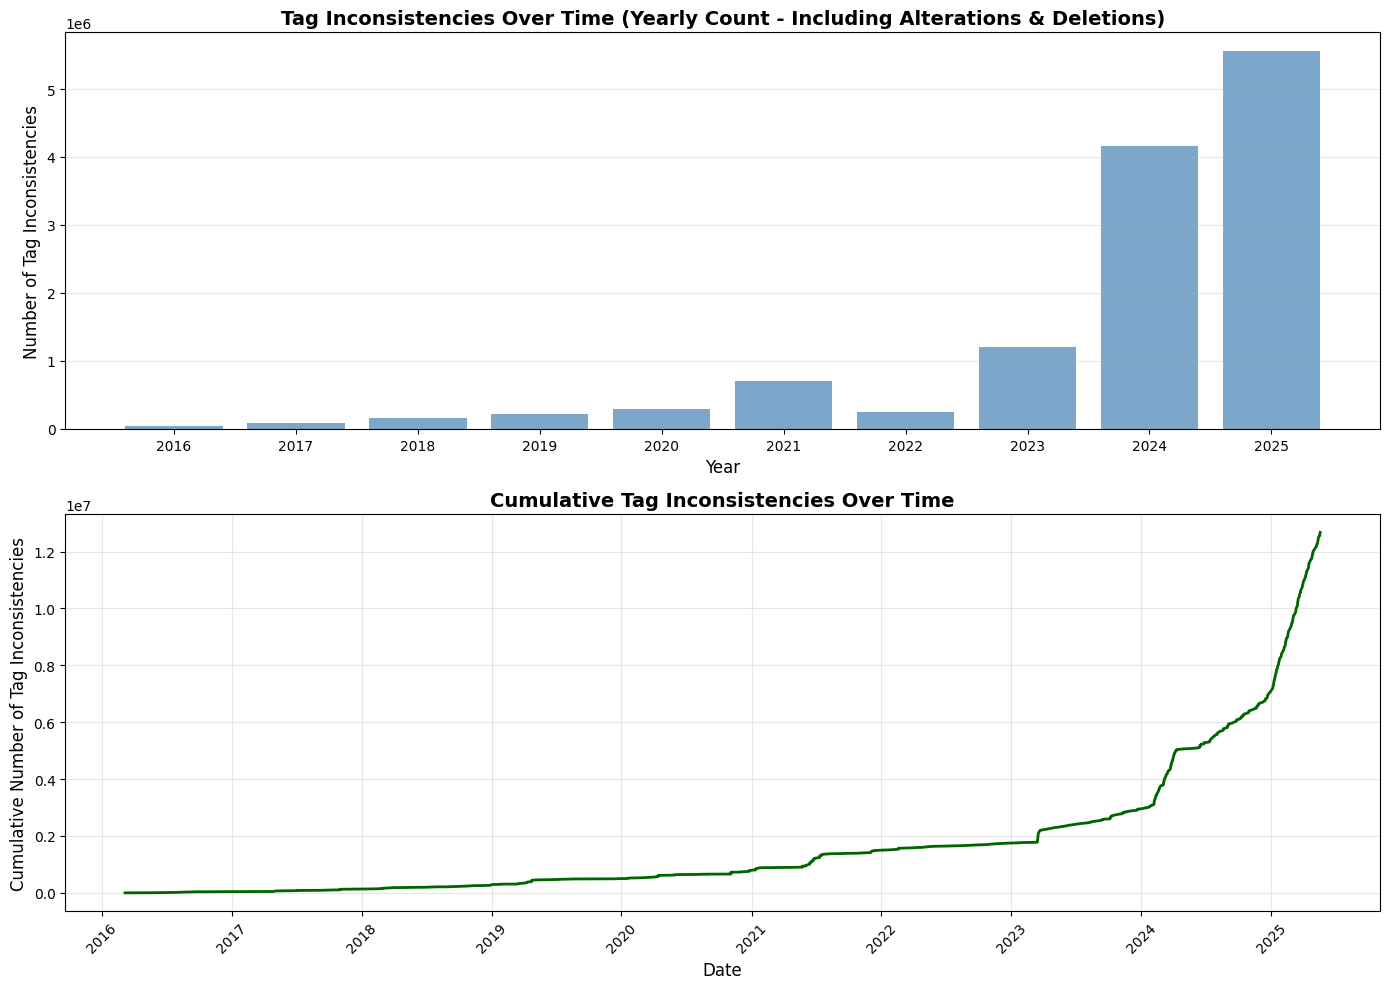

Total tag inconsistencies plotted: 12673979
  - Tag Alterations: 171356
  - Tag Deletions: 12502623
Date range: 2016-03-06 04:10:12 to 2025-05-18 20:25:54


In [11]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

df_sorted = df.sort_values('new_snap_timestamp')
df_sorted['cumulative_count'] = range(1, len(df_sorted) + 1)

df['year'] = df['new_snap_timestamp'].dt.year
inconsistencies_by_year = df.groupby('year').size()

ax1.bar(inconsistencies_by_year.index, inconsistencies_by_year.values, width=0.8, alpha=0.7, color='steelblue')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Number of Tag Inconsistencies', fontsize=12)
ax1.set_title('Tag Inconsistencies Over Time (Yearly Count - Including Alterations & Deletions)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_xticks(inconsistencies_by_year.index)

ax2.plot(df_sorted['new_snap_timestamp'], 
         df_sorted['cumulative_count'], 
         linewidth=2, color='darkgreen')
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Cumulative Number of Tag Inconsistencies', fontsize=12)
ax2.set_title('Cumulative Tag Inconsistencies Over Time', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"Total tag inconsistencies plotted: {len(df)}")
print(f"  - Tag Alterations: {len(tag_alterations)}")
print(f"  - Tag Deletions: {len(tag_deletions)}")
print(f"Date range: {df['new_snap_timestamp'].min()} to {df['new_snap_timestamp'].max()}")

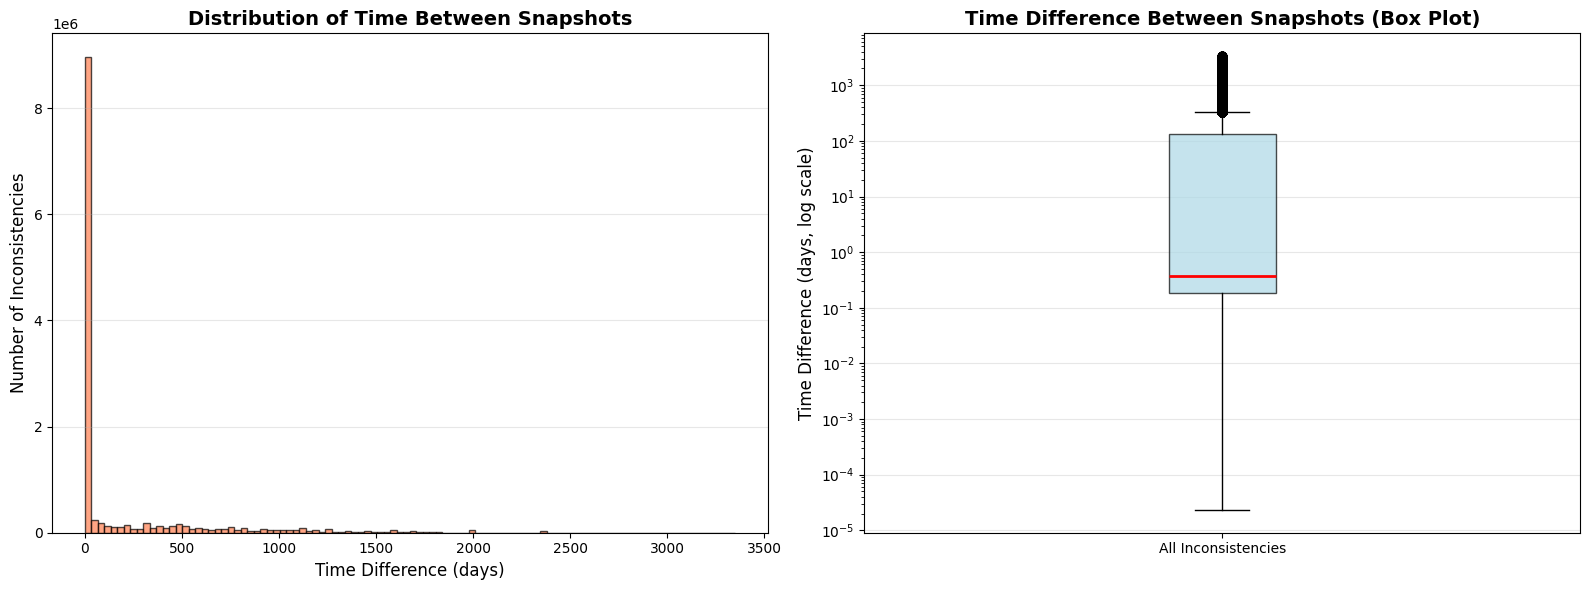

Time difference statistics:
  Mean: 191.59 days
  Median: 0.37 days
  Min: 0.00 days
  Max: 3349.81 days
  Std: 409.07 days


In [12]:
df['time_diff_days'] = (df['new_snap_timestamp'] - df['old_snap_timestamp']).dt.total_seconds() / (24 * 3600)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

time_diffs_filtered = df['time_diff_days'].dropna()
ax1.hist(time_diffs_filtered, bins=100, alpha=0.7, color='coral', edgecolor='black')
ax1.set_xlabel('Time Difference (days)', fontsize=12)
ax1.set_ylabel('Number of Inconsistencies', fontsize=12)
ax1.set_title('Distribution of Time Between Snapshots', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

ax2.boxplot([time_diffs_filtered[time_diffs_filtered > 0]], vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightblue', alpha=0.7),
            medianprops=dict(color='red', linewidth=2))
ax2.set_ylabel('Time Difference (days, log scale)', fontsize=12)
ax2.set_title('Time Difference Between Snapshots (Box Plot)', fontsize=14, fontweight='bold')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_xticklabels(['All Inconsistencies'])

plt.tight_layout()
plt.show()

print(f"Time difference statistics:")
print(f"  Mean: {time_diffs_filtered.mean():.2f} days")
print(f"  Median: {time_diffs_filtered.median():.2f} days")
print(f"  Min: {time_diffs_filtered.min():.2f} days")
print(f"  Max: {time_diffs_filtered.max():.2f} days")
print(f"  Std: {time_diffs_filtered.std():.2f} days")

/tmp/ipykernel_3962645/665565989.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tag_alterations['rev_time_diff_days'] = (tag_alterations['new_rev_timestamp'] - tag_alterations['old_rev_timestamp']).dt.total_seconds() / (24 * 3600)


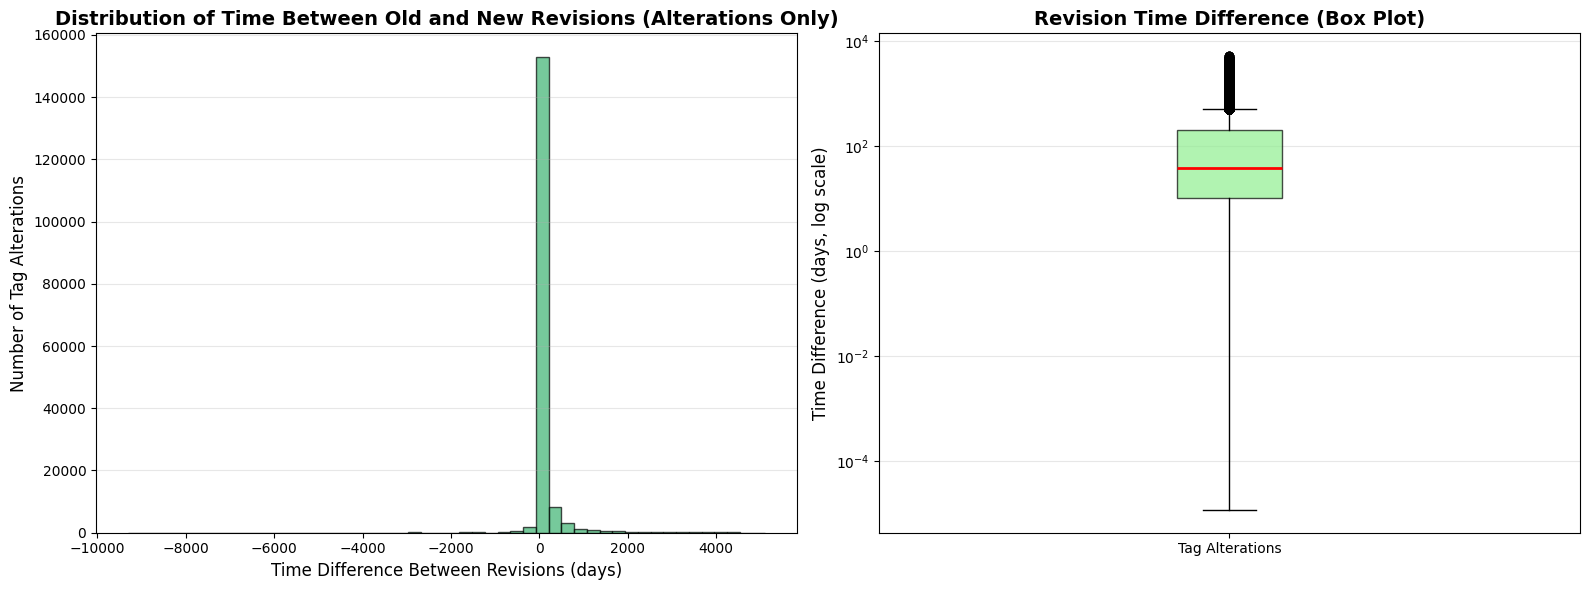

Revision time difference statistics (for 171356 alterations):
  Mean: 71.61 days
  Median: 0.00 days
  Min: -9308.67 days
  Max: 5109.00 days
  Std: 368.93 days
  Negative values (new revision older than old): 10504


In [13]:
tag_alterations['rev_time_diff_days'] = (tag_alterations['new_rev_timestamp'] - tag_alterations['old_rev_timestamp']).dt.total_seconds() / (24 * 3600)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

rev_time_diffs = tag_alterations['rev_time_diff_days'].dropna()
ax1.hist(rev_time_diffs, bins=50, alpha=0.7, color='mediumseagreen', edgecolor='black')
ax1.set_xlabel('Time Difference Between Revisions (days)', fontsize=12)
ax1.set_ylabel('Number of Tag Alterations', fontsize=12)
ax1.set_title('Distribution of Time Between Old and New Revisions (Alterations Only)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

positive_rev_diffs = rev_time_diffs[rev_time_diffs > 0]
if len(positive_rev_diffs) > 0:
    ax2.boxplot([positive_rev_diffs], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightgreen', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
    ax2.set_ylabel('Time Difference (days, log scale)', fontsize=12)
    ax2.set_title('Revision Time Difference (Box Plot)', fontsize=14, fontweight='bold')
    ax2.set_yscale('log')
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.set_xticklabels(['Tag Alterations'])

plt.tight_layout()
plt.show()

print(f"Revision time difference statistics (for {len(tag_alterations)} alterations):")
print(f"  Mean: {rev_time_diffs.mean():.2f} days")
print(f"  Median: {rev_time_diffs.median():.2f} days")
print(f"  Min: {rev_time_diffs.min():.2f} days")
print(f"  Max: {rev_time_diffs.max():.2f} days")
print(f"  Std: {rev_time_diffs.std():.2f} days")
print(f"  Negative values (new revision older than old): {len(rev_time_diffs[rev_time_diffs < 0])}")

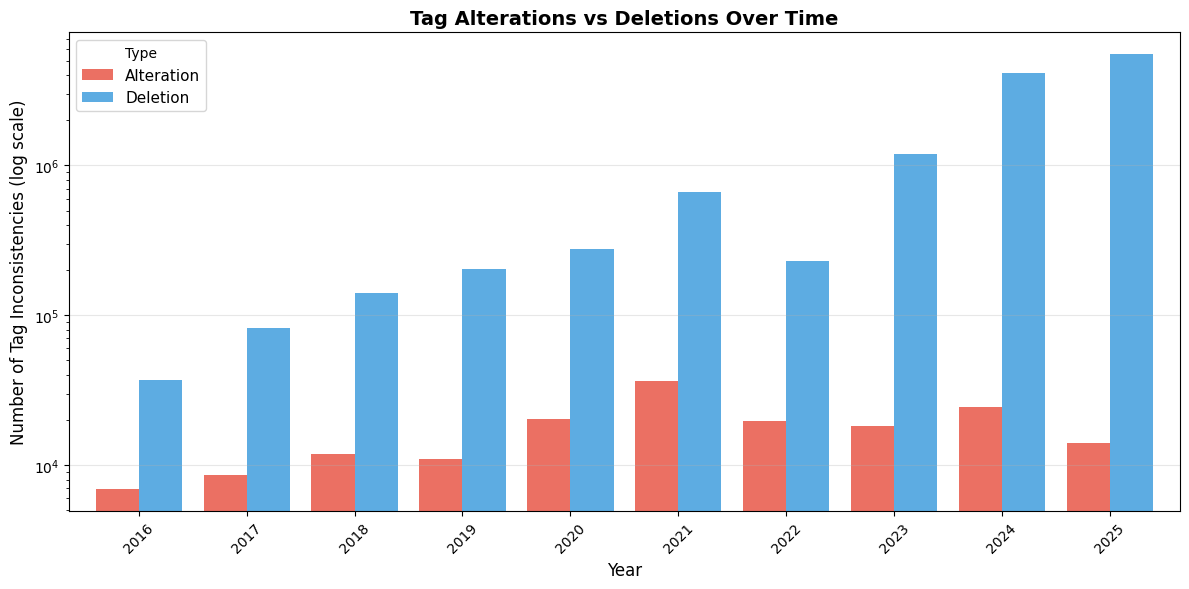


Yearly breakdown:
type  Alteration  Deletion
year                      
2016        6899     37115
2017        8590     81814
2018       11904    140389
2019       11025    204006
2020       20352    275973
2021       36558    666725
2022       19553    230999
2023       18125   1185246
2024       24234   4137976
2025       14116   5542380

Total Alterations: 171356
Total Deletions: 12502623


In [14]:
inconsistencies_by_year_type = df.groupby(['year', 'type']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))

inconsistencies_by_year_type.plot(kind='bar', ax=ax, 
                                   color=['#e74c3c', '#3498db'], alpha=0.8, width=0.8)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Tag Inconsistencies (log scale)', fontsize=12)
ax.set_title('Tag Alterations vs Deletions Over Time', fontsize=14, fontweight='bold')
ax.legend(title='Type', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.tick_params(axis='x', rotation=45)
ax.set_yscale('log')  # Log scale to see alterations better

plt.tight_layout()
plt.show()

print("\nYearly breakdown:")
print(inconsistencies_by_year_type)
print(f"\nTotal Alterations: {inconsistencies_by_year_type['Alteration'].sum()}")
print(f"Total Deletions: {inconsistencies_by_year_type['Deletion'].sum()}")

## Last. Close Database Connection

In [15]:
conn.close()
print("Database connection closed")

Database connection closed
